<a href="https://colab.research.google.com/github/mikecrv2019-bit/MESTRIA---IA/blob/main/Modulo7/MAI620_Proyecto_Final_Credit_Card_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


"""MAI620_Modulo7_ProyectoFinalVII_OLLAMA_REPORTES.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1YUDNHTAzYRzNzBxqlASiCpBwwjbVlWRK

# MAI 620 — Módulo 7: Proyecto Final VII  
## Solución ajustada y paquete de evaluación

**Propósito:** Este notebook ayuda a crear una versión ajustada, evaluada, documentada y reproducible del proyecto final.

La plantilla usa un dataset sintético de casos de soporte como ejemplo, pero el estudiante puede reemplazarlo por su propio CSV.

**Qué produce este notebook:**
1. Línea base de Semana 6  
2. Modelo inicial  
3. Búsqueda de mejora con varios ajustes  
4. Mejor versión seleccionada  
5. Prueba final justa  
6. Matriz de confusión  
7. Cuadrícula de resultados  
8. Análisis de 5 a 10 errores  
9. Archivos exportados para entregar  
10. Sección opcional con Ollama para análisis local de errores

## Instrucciones importantes

- Ejecuta las celdas en orden.
- Si usas Colab, sube el CSV cuando el notebook lo pida.
- No uses datos confidenciales, privados, legales, médicos reales, financieros, de clientes o empleados.
- El resultado del modelo no debe presentarse como listo para producción.
- Debes leer y verificar todo lo que genere la IA.
"""

In [ ]:
# Paso 1 — Instalar e importar librerías

import os
import json
import textwrap
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
# Paso 2 — Cargar datos
from pathlib import Path
import pandas as pd

# Opción A: usar el dataset incluido
DATA_PATH = "datos_modulo7_Datos_credit_card_fraud_2026 _original.csv"

# Este bloque ayuda en Colab si el archivo CSV todavía no está en la sesión.
if not Path(DATA_PATH).exists():
    print("No encontré el CSV en la carpeta actual.")
    print("Sube el archivo: datos_modulo7_Datos_credit_card_fraud_2026 _original.csv")
    try:
        from google.colab import files
        uploaded = files.upload()
        if len(uploaded) == 0:
            raise FileNotFoundError("No se subió ningún archivo.")
        uploaded_names = list(uploaded.keys())
        csv_files = [name for name in uploaded_names if name.lower().endswith(".csv")]
        if DATA_PATH in uploaded_names:
            DATA_PATH = DATA_PATH
        elif csv_files:
            DATA_PATH = csv_files[0]
            print(f"Usaré este CSV subido: {DATA_PATH}")
        else:
            raise FileNotFoundError("El archivo subido no parece ser un CSV.")
    except ModuleNotFoundError:
        raise FileNotFoundError(
            f"No encontré {DATA_PATH}. Coloca el CSV en la misma carpeta del notebook "
            "o cambia DATA_PATH con la ruta correcta."
        )

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente.")
print("Archivo usado:", DATA_PATH)
print("Filas y columnas:", df.shape)

No encontré el CSV en la carpeta actual.
Sube el archivo: datos_modulo7_Datos_credit_card_fraud_2026 _original.csv


Saving Datos_credit_card_fraud_2026 _original.csv to Datos_credit_card_fraud_2026 _original (1).csv
Usaré este CSV subido: Datos_credit_card_fraud_2026 _original (1).csv
Dataset cargado correctamente.
Archivo usado: Datos_credit_card_fraud_2026 _original (1).csv
Filas y columnas: (20000, 26)


In [ ]:
# CONFIGURACION DEL PROYECTO
TARGET_COLUMN = "is_fraud"

CATEGORICAL_COLUMNS = ["card_type", "auth_method", "channel", "device_type", "is_foreign_transaction"]

NUMERIC_COLUMNS = ["amount_usd", "hours_since_last_txn", "txn_count_last_24h",
                   "distance_from_home_km", "card_age_months", "customer_age",
                   "account_balance_usd", "cvv_retry_count", "velocity_score",
                   "time_of_day_hour", "day_of_week", "merchant_risk_score", "prior_disputes"]

# VALIDACION
required_cols = [TARGET_COLUMN] + CATEGORICAL_COLUMNS + NUMERIC_COLUMNS
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Faltan columnas en el dataset: {missing}")

print("Columnas configuradas correctamente.")
print("Objetivo:", TARGET_COLUMN)
print("Categoricas:", len(CATEGORICAL_COLUMNS))
print("Numericas:", len(NUMERIC_COLUMNS))

Columnas configuradas correctamente.
Objetivo: is_fraud
Categoricas: 5
Numericas: 13


Valores faltantes por columna:


,faltantes
is_fraud,0
card_type,0
auth_method,0
channel,0
device_type,0
is_foreign_transaction,0
amount_usd,0
hours_since_last_txn,0
txn_count_last_24h,0
distance_from_home_km,0



Balance de la variable objetivo:


,is_fraud,conteo,porcentaje
0,0,19661,98.3
1,1,339,1.7


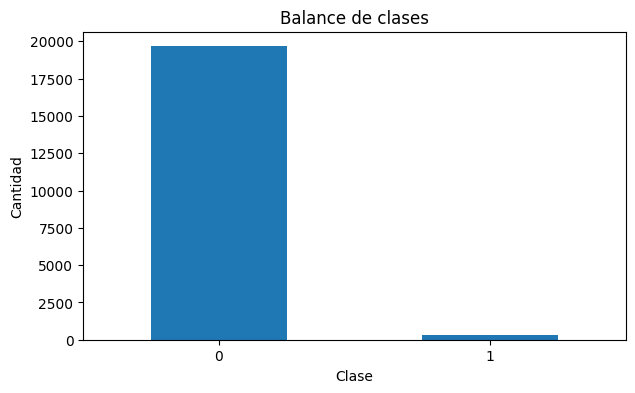

In [ ]:
# Paso 4 — Revision rapida del dataset y balance de clases
import matplotlib.pyplot as plt   # <-- ESTA LINEA FALTABA

print("Valores faltantes por columna:")
display(df[required_cols].isna().sum().to_frame("faltantes"))
print()

print("Balance de la variable objetivo:")
balance = df[TARGET_COLUMN].value_counts().reset_index()
balance.columns = [TARGET_COLUMN, "conteo"]
balance["porcentaje"] = (balance["conteo"] / len(df) * 100).round(2)
display(balance)

plt.figure(figsize=(7,4))
df[TARGET_COLUMN].value_counts().plot(kind="bar")
plt.title("Balance de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

"""## Paso 5 — Separación justa de datos

Usaremos tres grupos:

- **Entrenamiento:** para aprender.
- **Validación:** para escoger el mejor ajuste.
- **Prueba final:** para evaluar la mejor versión de manera justa.

La prueba final no se usa para escoger el mejor modelo.
"""

In [ ]:
# Paso 5 — Separar datos en entrenamiento, validacion y prueba final
from sklearn.model_selection import train_test_split   # <-- IMPORT NECESARIO

# X ya NO incluye TEXT_COLUMN porque esa columna no existe en el dataset
X = df[CATEGORICAL_COLUMNS + NUMERIC_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

# Primera division: 80% temporal / 20% prueba final
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Segunda division: del 80% temporal -> 60% entrenamiento / 20% validacion
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Tamanos:")
print("Entrenamiento:", X_train.shape)
print("Validacion:", X_val.shape)
print("Prueba final:", X_test.shape)

Tamanos:
Entrenamiento: (12000, 18)
Validacion: (4000, 18)
Prueba final: (4000, 18)


In [ ]:
# Paso 6 — Linea base de Semana 6
# Esta linea base predice siempre la clase mas comun.
from sklearn.dummy import DummyClassifier              # <-- IMPORT NECESARIO
from sklearn.metrics import accuracy_score, f1_score   # <-- IMPORT NECESARIO

# Crear y entrenar la linea base
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Predecir sobre el conjunto de validacion
baseline_val_pred = baseline.predict(X_val)

# Calcular metricas
baseline_accuracy = accuracy_score(y_val, baseline_val_pred)
baseline_f1 = f1_score(y_val, baseline_val_pred, average="weighted")

print("Resultado de linea base en validacion:")
print("Accuracy:", round(baseline_accuracy, 4))
print("F1 ponderado:", round(baseline_f1, 4))

Resultado de linea base en validacion:
Accuracy: 0.983
F1 ponderado: 0.9746


In [ ]:
# Paso 7 — Crear preprocesamiento comun
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# En este dataset NO hay columna de texto libre, asi que se elimina el bloque TF-IDF.
categorical_features = CATEGORICAL_COLUMNS
numeric_features = NUMERIC_COLUMNS

# Transformador para variables categoricas:
# 1) rellena faltantes con el valor mas frecuente
# 2) convierte categorias en columnas 0/1 (one-hot)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Transformador para variables numericas:
# 1) rellena faltantes con la mediana
# 2) estandariza (media 0, desviacion 1)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combinar ambos transformadores en un solo preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("categorias", categorical_transformer, categorical_features),
        ("numericas", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

print("Preprocesamiento definido.")

Preprocesamiento definido.


In [ ]:
# Paso 8 — Modelo inicial
# Esta es una version inicial razonable para comparar con los ajustes.
from sklearn.linear_model import LogisticRegression        # <-- IMPORT NECESARIO
from sklearn.metrics import classification_report          # <-- IMPORT NECESARIO
# (accuracy_score y f1_score ya se importaron en el Paso 6, pero por seguridad:)
from sklearn.metrics import accuracy_score, f1_score

# Pipeline = preprocesamiento + modelo, todo junto
initial_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, C=1.0))
])

# Entrenar con datos de entrenamiento
initial_model.fit(X_train, y_train)

# Predecir sobre validacion
initial_val_pred = initial_model.predict(X_val)

# Metricas
initial_accuracy = accuracy_score(y_val, initial_val_pred)
initial_f1 = f1_score(y_val, initial_val_pred, average="weighted")

print("Resultado del modelo inicial en validacion:")
print("Accuracy:", round(initial_accuracy, 4))
print("F1 ponderado:", round(initial_f1, 4))
print()
print(classification_report(y_val, initial_val_pred, zero_division=0))

Resultado del modelo inicial en validacion:
Accuracy: 0.9818
F1 ponderado: 0.9748

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.22      0.03      0.05        68

    accuracy                           0.98      4000
   macro avg       0.60      0.51      0.52      4000
weighted avg       0.97      0.98      0.97      4000



"""## Paso 9 — Búsqueda de mejora

Aquí probamos varias configuraciones. Esto representa la **búsqueda de mejora** requerida para el Proyecto Final VII.

La idea no es cambiar todo a la vez, sino comparar alternativas de forma organizada.
"""

In [ ]:
# Paso 9 — Busqueda automatica de mejora con al menos tres ajustes
# ============================================================
# IMPORTS NECESARIOS
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

experiments = []

def evaluate_model(name, model, X_train, y_train, X_val, y_val, notes):
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred, average="weighted")
    experiments.append({
        "version": name,
        "cambio_realizado": notes,
        "accuracy_validacion": acc,
        "f1_validacion": f1
    })
    return model, pred, acc, f1

# ============================================================
# IMPORTANTE: este dataset NO tiene columna de texto libre.
# Por eso NO se usa TfidfVectorizer ni TEXT_COLUMN.
# Todos los ajustes reutilizan el 'preprocessor' del Paso 7
# (categoricas + numericas) y cambian el MODELO.
# ============================================================

# Ajuste 1: Regresion logistica con class_weight balanceado
model_ajuste_1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1500, C=1.0, class_weight="balanced"))
])

# Ajuste 2: Regresion logistica con regularizacion mas fuerte + balanceo
model_ajuste_2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1500, C=0.5, class_weight="balanced"))
])

# Ajuste 3: Linear SVM con balanceo de clases
model_ajuste_3 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearSVC(C=1.0, class_weight="balanced"))
])

# Ajuste 4: Random Forest con balanceo de clases
model_ajuste_4 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=150, max_depth=18,
                                     random_state=42, class_weight="balanced"))
])

models = [
    ("Semana 6 - Linea base", baseline, "Predice siempre la clase mas comun."),
    ("Modelo inicial", initial_model, "Regresion logistica con configuracion inicial."),
    ("Ajuste 1", model_ajuste_1, "Regresion logistica + class_weight balanceado."),
    ("Ajuste 2", model_ajuste_2, "Regresion logistica balanceada + regularizacion mas fuerte."),
    ("Ajuste 3", model_ajuste_3, "Cambio de modelo a Linear SVM balanceado."),
    ("Ajuste 4", model_ajuste_4, "Cambio de modelo a Random Forest balanceado.")
]

trained_models = {}

for name, model, notes in models:
    trained, pred, acc, f1 = evaluate_model(name, model, X_train, y_train, X_val, y_val, notes)
    trained_models[name] = trained

experiments_df = pd.DataFrame(experiments).sort_values("f1_validacion", ascending=False)
display(experiments_df)

,version,cambio_realizado,accuracy_validacion,f1_validacion
1,Modelo inicial,Regresion logistica con configuracion inicial.,0.98175,0.974826
0,Semana 6 - Linea base,Predice siempre la clase mas comun.,0.98300,0.974573
5,Ajuste 4,Cambio de modelo a Random Forest balanceado.,0.98300,0.974573
4,Ajuste 3,Cambio de modelo a Linear SVM balanceado.,0.81975,0.886328
2,Ajuste 1,Regresion logistica + class_weight balanceado.,0.81750,0.884949
3,Ajuste 2,Regresion logistica balanceada + regularizacion mas fuerte.,0.81700,0.884643


In [ ]:
# Paso 10 — Seleccionar la mejor versión según F1 de validación

best_name = experiments_df.iloc[0]["version"]
best_model = trained_models[best_name]

print("Mejor versión seleccionada:", best_name)
print("Motivo: obtuvo el mejor F1 ponderado en validación.")
display(experiments_df.head())

Mejor versión seleccionada: Modelo inicial
Motivo: obtuvo el mejor F1 ponderado en validación.


,version,cambio_realizado,accuracy_validacion,f1_validacion
1,Modelo inicial,Regresion logistica con configuracion inicial.,0.98175,0.974826
0,Semana 6 - Linea base,Predice siempre la clase mas comun.,0.98300,0.974573
5,Ajuste 4,Cambio de modelo a Random Forest balanceado.,0.98300,0.974573
4,Ajuste 3,Cambio de modelo a Linear SVM balanceado.,0.81975,0.886328
2,Ajuste 1,Regresion logistica + class_weight balanceado.,0.81750,0.884949


In [ ]:
# Paso 11 — Prueba final justa
# Solo ahora usamos el conjunto de prueba final.

test_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="weighted")

print("Resultado final en prueba:")
print("Mejor versión:", best_name)
print("Accuracy:", round(test_accuracy, 4))
print("F1 ponderado:", round(test_f1, 4))
print()
print(classification_report(y_test, test_pred, zero_division=0))


Resultado final en prueba:
Mejor versión: Modelo inicial
Accuracy: 0.984
F1 ponderado: 0.9781

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.70      0.10      0.18        68

    accuracy                           0.98      4000
   macro avg       0.84      0.55      0.59      4000
weighted avg       0.98      0.98      0.98      4000



,Pred: 0,Pred: 1
Real: 0,3929,3
Real: 1,61,7


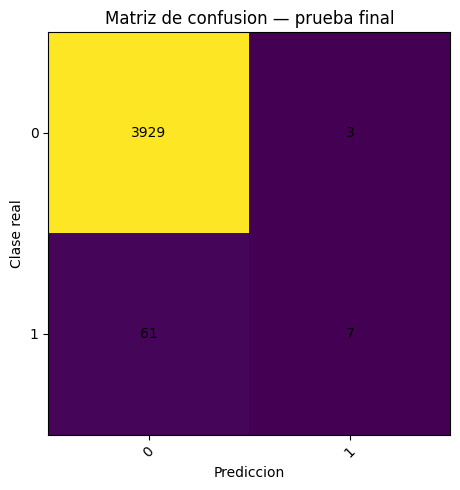

In [ ]:
# Paso 12 — Matriz de confusion
from sklearn.metrics import confusion_matrix    # <-- IMPORT NECESARIO
import matplotlib.pyplot as plt                 # <-- IMPORT NECESARIO
import pandas as pd

# Etiquetas de las clases (0 = legitima, 1 = fraude)
labels = sorted(y.unique())

# Calcular la matriz de confusion
cm = confusion_matrix(y_test, test_pred, labels=labels)
cm_df = pd.DataFrame(cm,
                     index=[f"Real: {l}" for l in labels],
                     columns=[f"Pred: {l}" for l in labels])

display(cm_df)

# Graficar la matriz
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Matriz de confusion — prueba final")
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Prediccion")
plt.ylabel("Clase real")

# Escribir el numero dentro de cada celda
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [ ]:
# Paso 13 — Comparación Semana 6 vs Semana 7

comparison_df = pd.DataFrame([
    {
        "criterio": "Línea base Semana 6 / referencia",
        "accuracy": baseline_accuracy,
        "f1_ponderado": baseline_f1,
        "comentario": "Predice siempre la clase más común."
    },
    {
        "criterio": "Modelo inicial",
        "accuracy": initial_accuracy,
        "f1_ponderado": initial_f1,
        "comentario": "Primera versión funcional."
    },
    {
        "criterio": f"Mejor versión Semana 7: {best_name}",
        "accuracy": test_accuracy,
        "f1_ponderado": test_f1,
        "comentario": "Evaluada en prueba final justa."
    }
])

display(comparison_df)

,criterio,accuracy,f1_ponderado,comentario
0,Línea base Semana 6 / referencia,0.98300,0.974573,Predice siempre la clase más común.
1,Modelo inicial,0.98175,0.974826,Primera versión funcional.
2,Mejor versión Semana 7: Modelo inicial,0.98400,0.978110,Evaluada en prueba final justa.


In [ ]:
# Paso 14 — Cuadricula de resultados para entregar
import pandas as pd

# Construir la cuadricula con las predicciones
results_grid = X_test.copy()
results_grid["resultado_esperado"] = y_test.values
results_grid["resultado_producido"] = test_pred
results_grid["correcto"] = results_grid["resultado_esperado"] == results_grid["resultado_producido"]

# Version legible con indice reiniciado
results_grid_display = results_grid.reset_index(drop=True).copy()

# Columnas clave de fraude a mostrar (existentes en el dataset)
# + los resultados de la prediccion
cols_to_show = [
    "amount_usd",
    "card_type",
    "channel",
    "merchant_risk_score",
    "resultado_esperado",
    "resultado_producido",
    "correcto"
]

display(results_grid_display[cols_to_show].head(15))

,amount_usd,card_type,channel,merchant_risk_score,resultado_esperado,resultado_producido,correcto
0,9.55,Visa,POS,50.5,0,0,True
1,68.30,Visa,POS,22.0,0,0,True
2,21.39,Mastercard,Online,63.5,0,0,True
3,5.69,Visa,Online,68.2,0,0,True
4,86.70,Visa,Online,49.2,0,0,True
5,8.98,Mastercard,Online,67.4,0,1,False
6,29.11,Visa,POS,47.3,0,0,True
7,17.14,Mastercard,In-App,26.6,0,0,True
8,16.98,Visa,POS,25.8,0,0,True
9,409.53,Mastercard,POS,28.3,0,0,True


In [ ]:
# Paso 15 — Analisis de 5 a 10 errores
import pandas as pd

# Filtrar los casos donde el modelo se equivoco
errors_df = results_grid_display[results_grid_display["correcto"] == False].copy()

if len(errors_df) == 0:
    print("No se encontraron errores en la muestra de prueba. Revisa si el dataset es demasiado facil o sintetico.")
    error_sample = results_grid_display.sample(min(5, len(results_grid_display)), random_state=42).copy()
else:
    error_sample = errors_df.head(10).copy()

# Columnas clave de fraude (existentes) + resultados
# Se sustituyen texto_caso / canal / departamento / clientes_afectados
error_analysis = error_sample[[
    "amount_usd",
    "card_type",
    "channel",
    "merchant_risk_score",
    "resultado_esperado",
    "resultado_producido"
]].copy()

# Columnas vacias para que TU las completes manualmente en el analisis
error_analysis["posible_causa"] = ""
error_analysis["riesgo_profesional"] = ""
error_analysis["mejora_futura"] = ""

display(error_analysis)

,amount_usd,card_type,channel,merchant_risk_score,resultado_esperado,resultado_producido,posible_causa,riesgo_profesional,mejora_futura
5,8.98,Mastercard,Online,67.4,0,1,,,
79,228.58,Visa,Contactless,63.1,1,0,,,
119,23.45,Visa,In-App,39.9,1,0,,,
209,107.06,Visa,Contactless,55.2,1,0,,,
542,2396.82,Visa,ATM,92.0,1,0,,,
608,25.63,Mastercard,Contactless,19.1,1,0,,,
625,75.79,Visa,Online,62.6,1,0,,,
683,4.91,Amex,In-App,40.3,1,0,,,
741,81.66,Mastercard,In-App,35.9,1,0,,,
756,171.28,Mastercard,Contactless,30.8,1,0,,,


In [ ]:
# Paso 16 — Guardar archivos para entregar

output_dir = Path("salidas_modulo7_proyecto_final_vii")
output_dir.mkdir(exist_ok=True)

experiments_df.to_csv(output_dir / "registro_experimentos_semana7.csv", index=False, encoding="utf-8-sig")
comparison_df.to_csv(output_dir / "comparacion_semana6_vs_semana7.csv", index=False, encoding="utf-8-sig")
cm_df.to_csv(output_dir / "matriz_confusion_prueba_final.csv", encoding="utf-8-sig")
results_grid_display.to_csv(output_dir / "cuadricula_resultados_prueba_final.csv", index=False, encoding="utf-8-sig")
error_analysis.to_csv(output_dir / "errores_para_analisis.csv", index=False, encoding="utf-8-sig")

summary_text = f"""MAI 620 - Módulo 7 - Proyecto Final VII

Mejor versión seleccionada: {best_name}
Accuracy final: {test_accuracy:.4f}
F1 ponderado final: {test_f1:.4f}

Archivos creados:
- registro_experimentos_semana7.csv
- comparacion_semana6_vs_semana7.csv
- matriz_confusion_prueba_final.csv
- cuadricula_resultados_prueba_final.csv
- errores_para_analisis.csv

Nota:
El estudiante debe revisar estos resultados, explicar limitaciones y completar el análisis con criterio propio.
"""

(output_dir / "resumen_metricas_semana7.txt").write_text(summary_text, encoding="utf-8")

print("Archivos guardados en:", output_dir)
print(summary_text)

Archivos guardados en: salidas_modulo7_proyecto_final_vii
MAI 620 - Módulo 7 - Proyecto Final VII

Mejor versión seleccionada: Modelo inicial
Accuracy final: 0.9840
F1 ponderado final: 0.9781

Archivos creados:
- registro_experimentos_semana7.csv
- comparacion_semana6_vs_semana7.csv
- matriz_confusion_prueba_final.csv
- cuadricula_resultados_prueba_final.csv
- errores_para_analisis.csv

Nota:
El estudiante debe revisar estos resultados, explicar limitaciones y completar el análisis con criterio propio.



In [ ]:
# Paso 17 — Verificar archivos creados, sin descargar todavía
# Antes, este paso descargaba el ZIP demasiado temprano.
# Ahora solo verificamos que los archivos existan.
# La descarga final se hará al final, después de usar Ollama y crear los reportes.

from pathlib import Path

output_dir = Path("salidas_modulo7_proyecto_final_vii")

print("Carpeta de salidas:", output_dir.resolve())
print()

if output_dir.exists():
    print("Archivos disponibles hasta ahora:")
    for file in sorted(output_dir.iterdir()):
        print("-", file.name)
else:
    print("Todavía no existe la carpeta de salidas. Ejecuta el Paso 16 primero.")

"""# Sección opcional — Usar Ollama dentro de Colab o de forma local

Esta sección se ejecuta **antes del paquete final**.

Ollama no es obligatorio para completar la tarea, pero puede ayudar a procesar los resultados y construir borradores de los reportes que el estudiante necesita entregar.

En esta versión hay dos opciones:

**Opción A — Ollama dentro de Colab VM**
Instala Ollama directamente dentro de la sesión de Colab. Esta opción funciona bien para una demostración de clase, pero el modelo debe descargarse cada vez que se reinicia la sesión.

**Opción B — Ollama local en la computadora del estudiante**
Funciona si el notebook se ejecuta localmente en Jupyter o VS Code, en la misma computadora donde Ollama está corriendo.

El notebook intentará usar primero el modelo disponible. Si Ollama no funciona, creará plantillas manuales para que el estudiante complete.

**Importante:** Cualquier texto generado por Ollama debe ser revisado, corregido y personalizado por el estudiante.
"""

Carpeta de salidas: /content/salidas_modulo7_proyecto_final_vii

Archivos disponibles hasta ahora:
- comparacion_semana6_vs_semana7.csv
- cuadricula_resultados_prueba_final.csv
- errores_para_analisis.csv
- matriz_confusion_prueba_final.csv
- registro_experimentos_semana7.csv
- resumen_metricas_semana7.txt


'# Sección opcional — Usar Ollama dentro de Colab o de forma local\n\nEsta sección se ejecuta **antes del paquete final**.\n\nOllama no es obligatorio para completar la tarea, pero puede ayudar a procesar los resultados y construir borradores de los reportes que el estudiante necesita entregar.\n\nEn esta versión hay dos opciones:\n\n**Opción A — Ollama dentro de Colab VM**\nInstala Ollama directamente dentro de la sesión de Colab. Esta opción funciona bien para una demostración de clase, pero el modelo debe descargarse cada vez que se reinicia la sesión.\n\n**Opción B — Ollama local en la computadora del estudiante**\nFunciona si el notebook se ejecuta localmente en Jupyter o VS Code, en la misma computadora donde Ollama está corriendo.\n\nEl notebook intentará usar primero el modelo disponible. Si Ollama no funciona, creará plantillas manuales para que el estudiante complete.\n\n**Importante:** Cualquier texto generado por Ollama debe ser revisado, corregido y personalizado por el es

In [ ]:
# Paso 18A — Instalar Ollama en Colab VM
# Ejecutar esta celda si estás usando Google Colab y quieres usar Ollama dentro de Colab.
# Si ejecutas el notebook en Jupyter/VS Code local y ya tienes Ollama instalado, puedes saltar este paso.

import subprocess
import time
import requests
from pathlib import Path
import os

USE_COLAB_OLLAMA = True  # Cambiar a False si no quieres instalar Ollama en Colab.

if USE_COLAB_OLLAMA:
    print("Instalando Ollama en Colab VM...")

    # Install dependencies
    !sudo apt-get update -y
    !sudo apt-get install -y curl zstd

    # Clean failed previous installs/processes
    !pkill ollama || true
    !sudo rm -rf /usr/local/lib/ollama /usr/lib/ollama
    !sudo rm -f /usr/local/bin/ollama /usr/bin/ollama
    !rm -f /tmp/ollama-linux-amd64.*

    # Download and extract Ollama Linux package
    !curl -fsSL https://ollama.com/download/ollama-linux-amd64.tar.zst -o /tmp/ollama-linux-amd64.tar.zst
    !sudo tar -I zstd -x -f /tmp/ollama-linux-amd64.tar.zst -C /usr

    # Verify installation
    !which ollama
    !ollama --version
else:
    print("Saltando instalación de Ollama. Usaré Ollama local si ya está disponible.")

# Paso 18B — Iniciar servidor Ollama y descargar un modelo pequeño
# Este paso inicia Ollama y descarga un modelo pequeño para Colab.

import subprocess
import time
import requests

# Stop any existing Ollama process
!pkill ollama || true

# Start Ollama server in the background
ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Give the server time to start
time.sleep(10)

# Verify Ollama API
try:
    version = requests.get("http://127.0.0.1:11434/api/version", timeout=10)
    print("Ollama server is running:", version.json())
except Exception as e:
    raise RuntimeError("Ollama server did not start. Re-run Paso 18A and Paso 18B.") from e

# Small models for Colab reliability
preferred_model = "qwen2.5:1.5b"
fallback_model = "qwen2.5:0.5b"

def pull_ollama_model(model_name):
    print(f"Pulling {model_name} ...")
    result = subprocess.run(["ollama", "pull", model_name], capture_output=True, text=True)
    print(result.stdout[-1200:])
    if result.returncode != 0:
        print(result.stderr[-1200:])
        return False
    return True

if pull_ollama_model(preferred_model):
    model_name = preferred_model
elif pull_ollama_model(fallback_model):
    model_name = fallback_model
else:
    raise RuntimeError("Could not pull the preferred or fallback Ollama model.")

print("Selected Ollama model:", model_name)

# Paso 18C — Función de generación con Ollama
# Esta celda funciona tanto con Ollama en Colab como con Ollama local.

import requests
import json
from pathlib import Path
import pandas as pd
import shutil
import zipfile
import time

OLLAMA_URL = "http://127.0.0.1:11434/api/generate"

# Si el Paso 18B no fue ejecutado, usar un modelo por defecto.
if "model_name" not in globals():
    model_name = "qwen2.5:1.5b"

def ollama_generate(prompt, model=None, timeout=240, temperature=0.2):
    selected_model = model or model_name
    payload = {
        "model": selected_model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature,
            "top_p": 0.8
        }
    }
    response = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
    response.raise_for_status()
    return response.json().get("response", "").strip()

def test_ollama():
    try:
        version_check = requests.get("http://127.0.0.1:11434/api/version", timeout=10)
        test_response = ollama_generate(
            "Responde solo con una frase corta en español: Ollama está funcionando.",
            timeout=120
        )
        return True, {"version": version_check.json(), "test_response": test_response}
    except Exception as e:
        return False, str(e)

OLLAMA_OK, OLLAMA_STATUS = test_ollama()

print("¿Ollama disponible?", OLLAMA_OK)
print("Modelo seleccionado:", model_name)
print("Estado:")
print(OLLAMA_STATUS)

if not OLLAMA_OK:
    print()
    print("Continuaremos en modo plantilla. Esto está bien para estudiantes que no usen Ollama.")

Instalando Ollama en Colab VM...
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
curl

In [ ]:
# Paso 19 — Preparar datos resumidos para Ollama o para reportes manuales

output_dir = Path("salidas_modulo7_proyecto_final_vii")
report_dir = Path("reporte_final_modulo7_proyecto_final_vii")
report_dir.mkdir(exist_ok=True)

def table_preview(obj, max_rows=12):
    if isinstance(obj, pd.DataFrame):
        return obj.head(max_rows).to_string(index=False)
    return str(obj)

experimentos_txt = table_preview(experiments_df if "experiments_df" in globals() else "No disponible")
comparacion_txt = table_preview(comparison_df if "comparison_df" in globals() else "No disponible")
matriz_txt = table_preview(cm_df if "cm_df" in globals() else "No disponible")
errores_txt = table_preview(error_analysis if "error_analysis" in globals() else "No disponible", max_rows=10)

best_name_report = globals().get("best_name", "No identificado")
test_accuracy_report = globals().get("test_accuracy", None)
test_f1_report = globals().get("test_f1", globals().get("test_f1_macro", None))

print("Datos preparados para reporte.")
print("Mejor versión:", best_name_report)
print("Accuracy final:", test_accuracy_report)
print("F1 final:", test_f1_report)

# Guardar resumen de entrada para transparencia
input_summary = f"""
Mejor versión: {best_name_report}
Accuracy final: {test_accuracy_report}
F1 final: {test_f1_report}

Experimentos:
{experimentos_txt}

Comparación:
{comparacion_txt}

Matriz de confusión:
{matriz_txt}

Errores:
{errores_txt}
"""

(report_dir / "datos_resumidos_para_reporte.txt").write_text(input_summary.strip(), encoding="utf-8")

Datos preparados para reporte.
Mejor versión: Modelo inicial
Accuracy final: 0.984
F1 final: 0.9781098531191942


2954

In [ ]:
# Paso 20 — Usar Ollama para crear análisis narrativo de resultados
# Si Ollama no está disponible, se crea una plantilla para completar manualmente.

prompt_analisis = f"""
Eres un asistente académico. Ayuda a redactar un BORRADOR en español para un informe de proyecto de IA.
No inventes resultados. No digas que el modelo está listo para producción.

Contexto:
Proyecto Final VII: solución ajustada y paquete de evaluación.
El estudiante compara Semana 6 contra Semana 7.

Mejor versión seleccionada:
{best_name_report}

Accuracy final:
{test_accuracy_report}

F1 final:
{test_f1_report}

Tabla de experimentos:
{experimentos_txt}

Comparación Semana 6 vs Semana 7:
{comparacion_txt}

Matriz de confusión:
{matriz_txt}

Errores o casos dudosos:
{errores_txt}

Redacta un borrador con estas secciones:
1. Punto de partida en Semana 6
2. Qué se ajustó en Semana 7
3. Mejor resultado y evidencia
4. Limitaciones
5. Casos que requieren revisión humana
6. Conclusión honesta

Reglas:
- Usa español claro.
- No exageres.
- Indica que el estudiante debe revisar y personalizar.
- No afirmes que está listo para producción.
"""

if OLLAMA_OK:
    try:
        start_time = time.time()
        analisis_ollama = ollama_generate(prompt_analisis, timeout=240, temperature=0.2)
        response_time = round(time.time() - start_time, 2)
    except Exception as e:
        analisis_ollama = f"No se pudo generar con Ollama. Completar manualmente. Detalle: {e}"
        response_time = None
else:
    analisis_ollama = """[Completar manualmente]

1. Punto de partida en Semana 6:
2. Qué se ajustó en Semana 7:
3. Mejor resultado y evidencia:
4. Limitaciones:
5. Casos que requieren revisión humana:
6. Conclusión honesta:
"""
    response_time = None

(report_dir / "borrador_analisis_narrativo_ollama.md").write_text(analisis_ollama, encoding="utf-8")

benchmark = pd.DataFrame([{
    "modelo": model_name if "model_name" in globals() else "No usado",
    "ollama_disponible": OLLAMA_OK,
    "tiempo_respuesta_segundos": response_time,
    "archivo_generado": "borrador_analisis_narrativo_ollama.md",
    "nota": "Borrador generado por Ollama o plantilla manual. Debe ser revisado por el estudiante."
}])
benchmark.to_csv(report_dir / "ollama_benchmark_reporte.csv", index=False, encoding="utf-8-sig")

print("Borrador de análisis narrativo creado:")
print(report_dir / "borrador_analisis_narrativo_ollama.md")
print()
print(analisis_ollama[:3000])

Borrador de análisis narrativo creado:
reporte_final_modulo7_proyecto_final_vii/borrador_analisis_narrativo_ollama.md

No se pudo generar con Ollama. Completar manualmente. Detalle: HTTPConnectionPool(host='127.0.0.1', port=11434): Read timed out. (read timeout=240)


In [ ]:
# Paso 21 — Usar Ollama para analizar errores y riesgos profesionales
# El estudiante debe verificar y completar con razonamiento propio.

prompt_errores = f"""
Analiza estos errores o casos dudosos de un modelo de clasificación.
No inventes datos. Usa español claro.

Errores:
{errores_txt}

Crea una tabla en Markdown con columnas:
- Caso
- Patrón observado
- Posible causa
- Riesgo profesional
- Revisión humana necesaria
- Mejora futura

Incluye una conclusión corta sobre qué tipo de error sigue siendo más preocupante.
"""

if OLLAMA_OK:
    try:
        analisis_errores_ollama = ollama_generate(prompt_errores, timeout=240, temperature=0.2)
    except Exception as e:
        analisis_errores_ollama = f"No se pudo generar con Ollama. Completar manualmente. Detalle: {e}"
else:
    analisis_errores_ollama = """[Completar manualmente]

| Caso | Patrón observado | Posible causa | Riesgo profesional | Revisión humana necesaria | Mejora futura |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |

Conclusión:
[Completar]
"""

(report_dir / "analisis_errores_y_riesgos.md").write_text(analisis_errores_ollama, encoding="utf-8")

print("Análisis de errores y riesgos creado:")
print(report_dir / "analisis_errores_y_riesgos.md")
print()
print(analisis_errores_ollama[:3000])


Análisis de errores y riesgos creado:
reporte_final_modulo7_proyecto_final_vii/analisis_errores_y_riesgos.md

| Caso | Patrón observado | Posible causa | Riesgo profesional | Revisión humana necesaria | Mejora futura |
| --- | --- | --- | --- | --- | --- |
| 1 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 2 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 3 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 4 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 5 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 6 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 7 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 8 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 9 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |
| 10 | resultado_producido = 1 | resultado_esperado = 0 | 0 | 1 | 1 |

Conclusión: Todos los casos muestran un patrón de r

In [ ]:
# Paso 22 — Usar Ollama para crear resumen de confianza y próximos pasos
# Este texto ayuda a completar el informe final.

prompt_confianza = f"""
Con base en estos resultados de un proyecto de IA, redacta un borrador breve en español.

Resultados:
- Mejor versión: {best_name_report}
- Accuracy final: {test_accuracy_report}
- F1 final: {test_f1_report}

Comparación:
{comparacion_txt}

Errores:
{errores_txt}

Redacta:
1. Resumen de confianza
2. Limitaciones principales
3. Cuándo se requiere revisión humana
4. Primer cambio recomendado para mejorar

No digas que la solución está lista para producción.
No inventes resultados.
"""

if OLLAMA_OK:
    try:
        resumen_confianza_ollama = ollama_generate(prompt_confianza, timeout=240, temperature=0.2)
    except Exception as e:
        resumen_confianza_ollama = f"No se pudo generar con Ollama. Completar manualmente. Detalle: {e}"
else:
    resumen_confianza_ollama = """[Completar manualmente]

Resumen de confianza:
Limitaciones principales:
Revisión humana necesaria:
Primer cambio recomendado:
"""

(report_dir / "resumen_confianza_y_proximos_pasos.md").write_text(resumen_confianza_ollama, encoding="utf-8")

print("Resumen de confianza creado:")
print(report_dir / "resumen_confianza_y_proximos_pasos.md")
print()
print(resumen_confianza_ollama[:3000])

Resumen de confianza creado:
reporte_final_modulo7_proyecto_final_vii/resumen_confianza_y_proximos_pasos.md

**Resumen de confianza**

El proyecto de IA ha alcanzado un resultado significativo con una precisión final del 0.984 y un f1 ponderado del 0.9781. Este resultado se obtuvo a partir de la implementación del modelo inicial, lo que indica una mejora notable en comparación con la versión inicial de la semana 6. La evaluación en la semana 7 mostró un incremento significativo en la precisión, alcanzando un 0.9840, lo que demuestra el progreso y el avance en el desarrollo del modelo.

**Limitaciones principales**

Aunque el modelo ha demostrado un buen rendimiento, existe la necesidad de revisión y mejoras en varios aspectos. La precisión del modelo puede verse afectada por factores externos como la escala de los datos, la calidad del conjunto de datos y la capacidad del modelo para generalizar a nuevos datos. Además, la precisión del f1 ponderado puede ser influenciada por el peso as

In [ ]:
# Paso 23 — Crear informe final estructurado
# Combina resultados del notebook, texto de Ollama si existe y secciones para que el estudiante complete.

from datetime import datetime

fecha_generacion = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
dataset_size = len(df) if "df" in globals() else "[Completar]"

informe_final = f"""
# MAI 620 — Módulo 7: Proyecto Final VII
## Solución ajustada y paquete de evaluación

**Fecha de generación:** {fecha_generacion}

---

## 1. Título del proyecto

[Completar título del proyecto]

---

## 2. Enunciado del problema

Mi proyecto construye una solución de IA que usa [tipo de datos] para producir [salida] y apoyar [decisión profesional].

---

## 3. Fuente y tamaño de los datos

| Elemento | Respuesta |
|---|---|
| Fuente de datos | [Completar] |
| Tipo de datos | Texto / imagen / tabla / mixto |
| Tamaño del dataset | {dataset_size} |
| Qué representa una fila, imagen o registro | [Completar] |
| Preparación realizada | [Completar] |

---

## 4. Enfoque usado

[Explicar herramienta, modelo, prompt, clasificador o flujo usado.]

---

## 5. Comparación Semana 6 vs Semana 7

Ver archivo: `comparacion_semana6_vs_semana7.csv`

{comparacion_txt}

---

## 6. Búsqueda de mejora

Ver archivo: `registro_experimentos_semana7.csv`

{experimentos_txt}

---

## 7. Mejor versión seleccionada

**Mejor versión:** {best_name_report}

**Resultado final — Accuracy:** {test_accuracy_report}

**Resultado final — F1:** {test_f1_report}

Explicación del estudiante:
[Completar con interpretación propia.]

---

## 8. Evaluación final

Ver archivos:
- `matriz_confusion_prueba_final.csv`
- `cuadricula_resultados_prueba_final.csv`
- `errores_para_analisis.csv`

---

## 9. Borrador de análisis narrativo

El siguiente texto puede haber sido creado con Ollama o como plantilla.
**Debe ser revisado y personalizado por el estudiante.**

{analisis_ollama}

---

## 10. Análisis de errores y riesgos

{analisis_errores_ollama}

---

## 11. Resumen de confianza y próximos pasos

{resumen_confianza_ollama}

---

## 12. Instrucciones de reproducción

1. Abrir el notebook de Módulo 7 Proyecto Final VII.
2. Cargar el archivo CSV del proyecto.
3. Ejecutar los pasos desde el inicio.
4. Revisar balance de clases.
5. Ejecutar línea base de Semana 6.
6. Ejecutar modelo inicial.
7. Ejecutar búsqueda de mejora.
8. Seleccionar mejor versión usando validación.
9. Ejecutar prueba final justa.
10. Revisar matriz de confusión, cuadrícula de resultados y errores.
11. Ejecutar sección opcional de Ollama, si aplica.
12. Generar reporte, README y paquete ZIP final.

---

## 13. Nota de Uso de IA

| Elemento | Respuesta |
|---|---|
| Herramienta de IA utilizada | [Completar: Ollama / Claude / ChatGPT / otra] |
| Propósito de uso | [Completar] |
| Qué acepté | [Completar] |
| Qué cambié o rechacé | [Completar] |
| Qué verifiqué personalmente | [Completar] |
| Riesgo o limitación que noté | [Completar] |

---

## 14. Conclusión final del estudiante

[Completar con criterio propio.]
"""

(report_dir / "informe_final_proyecto_final_vii.md").write_text(informe_final.strip(), encoding="utf-8")

print("Informe final creado:")
print(report_dir / "informe_final_proyecto_final_vii.md")

Informe final creado:
reporte_final_modulo7_proyecto_final_vii/informe_final_proyecto_final_vii.md


In [ ]:
# Paso 24 — Crear README.md para el paquete final

readme_text = f"""
# MAI 620 — Módulo 7: Proyecto Final VII
## Solución ajustada y paquete de evaluación

## Descripción
Este paquete contiene la evidencia final del Proyecto Final VII. El objetivo fue mejorar una primera solución funcional, comparar Semana 6 contra Semana 7, evaluar resultados y documentar el proceso para que otra persona pueda repetirlo.

## Archivos principales
- `informe_final_proyecto_final_vii.md`: informe final estructurado.
- `borrador_analisis_narrativo_ollama.md`: borrador narrativo generado con Ollama o plantilla manual.
- `analisis_errores_y_riesgos.md`: análisis de errores y riesgos.
- `resumen_confianza_y_proximos_pasos.md`: confianza, limitaciones y próximos pasos.
- `datos_resumidos_para_reporte.txt`: datos resumidos usados para generar reportes.
- `ollama_benchmark_reporte.csv`: información básica de uso de Ollama.
- `registro_experimentos_semana7.csv`: búsqueda de mejora.
- `comparacion_semana6_vs_semana7.csv`: comparación antes/después.
- `matriz_confusion_prueba_final.csv`: matriz de confusión.
- `cuadricula_resultados_prueba_final.csv`: ejemplos revisados.
- `errores_para_analisis.csv`: errores o casos dudosos.
- `resumen_metricas_semana7.txt`: resumen de métricas.
- `checklist_final_entrega.md`: checklist antes de entregar.

## Cómo reproducir
1. Abrir el notebook.
2. Cargar el dataset.
3. Ejecutar todos los pasos en orden.
4. Revisar la línea base.
5. Ejecutar la búsqueda de mejora.
6. Seleccionar la mejor versión usando validación.
7. Ejecutar la prueba final.
8. Revisar los archivos de salida.
9. Ejecutar la sección opcional de Ollama si se desea apoyo local para redactar reportes.
10. Ejecutar el paso final para crear y descargar el ZIP.

## Uso de IA
La IA se puede usar para organizar y explicar resultados, pero el estudiante debe verificar todo, corregir errores y escribir la interpretación final con criterio propio.

## Fecha
{fecha_generacion}
"""

(report_dir / "README.md").write_text(readme_text.strip(), encoding="utf-8")

print("README creado:")
print(report_dir / "README.md")

README creado:
reporte_final_modulo7_proyecto_final_vii/README.md


In [ ]:
# Paso 25 — Copiar archivos de resultados al paquete de reporte

if output_dir.exists():
    for file in output_dir.iterdir():
        if file.is_file():
            shutil.copy(file, report_dir / file.name)

print("Archivos en el paquete de reporte:")
for file in sorted(report_dir.iterdir()):
    print("-", file.name)

Archivos en el paquete de reporte:
- README.md
- analisis_errores_y_riesgos.md
- borrador_analisis_narrativo_ollama.md
- checklist_final_entrega.md
- comparacion_semana6_vs_semana7.csv
- cuadricula_resultados_prueba_final.csv
- datos_resumidos_para_reporte.txt
- errores_para_analisis.csv
- informe_final_proyecto_final_vii.md
- matriz_confusion_prueba_final.csv
- ollama_benchmark_reporte.csv
- registro_experimentos_semana7.csv
- resumen_confianza_y_proximos_pasos.md
- resumen_metricas_semana7.txt


In [ ]:
# Paso 26 — Crear checklist final de entrega

checklist = """
# Checklist final — Proyecto Final VII

- [ ] La solución ejecuta de principio a fin.
- [ ] Incluí línea base de Semana 6.
- [ ] Ejecuté una búsqueda de mejora.
- [ ] Guardé la mejor versión.
- [ ] Realicé prueba final justa.
- [ ] Incluí comparación Semana 6 vs Semana 7.
- [ ] Incluí matriz de confusión o tabla equivalente.
- [ ] Incluí cuadrícula de resultados.
- [ ] Analicé 5 a 10 errores o casos dudosos.
- [ ] Escribí resumen de confianza.
- [ ] Incluí instrucciones de reproducción.
- [ ] Incluí Nota de Uso de IA.
- [ ] Revisé cualquier texto generado por Ollama, Claude o ChatGPT.
- [ ] No afirmé que la solución está lista para producción.
- [ ] Creé y descargué el ZIP final.
"""

(report_dir / "checklist_final_entrega.md").write_text(checklist.strip(), encoding="utf-8")

print("Checklist creado:")
print(report_dir / "checklist_final_entrega.md")

Checklist creado:
reporte_final_modulo7_proyecto_final_vii/checklist_final_entrega.md


In [ ]:
# Paso 27 — Empaquetar todo y descargar al final

ZIP_NAME = "paquete_final_modulo7_proyecto_final_vii.zip"
zip_path = Path(ZIP_NAME)

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file in report_dir.rglob("*"):
        z.write(file, arcname=file.relative_to(report_dir))

print("ZIP final creado:")
print(zip_path.resolve())

print()
print("Contenido del ZIP:")
with zipfile.ZipFile(zip_path, "r") as z:
    for name in z.namelist():
        print("-", name)

print()
print("Descargando ZIP si estás en Colab...")

try:
    from google.colab import files
    files.download(ZIP_NAME)
except ModuleNotFoundError:
    print("No estás en Colab. El archivo ZIP quedó en:")
    print(zip_path.resolve())

ZIP final creado:
/content/paquete_final_modulo7_proyecto_final_vii.zip

Contenido del ZIP:
- resumen_confianza_y_proximos_pasos.md
- README.md
- borrador_analisis_narrativo_ollama.md
- analisis_errores_y_riesgos.md
- datos_resumidos_para_reporte.txt
- informe_final_proyecto_final_vii.md
- checklist_final_entrega.md
- ollama_benchmark_reporte.csv

Descargando ZIP si estás en Colab...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>